# Applying the Electome Factor models to your own LFP recordings

This notebook is the **tool manual**, not a showcase. Run it as-is on the two
example recordings shipped with the repository, then change one cell to point
it at your own data.

**What goes in** — per recording, three files:

| File | Contents | Required |
| --- | --- | --- |
| `*_LFP.mat` | one variable per recording site (`PrL_01` … `VTA_04`), raw traces | yes |
| `*_CHANS.mat` | `CHANNAMES` (site labels) and `CHANACTIVE` (0 = discard the site) | yes |
| `*.xlsx` / `.xls` / `.csv` | scored behaviour bouts, columns `START` / `STOP` in seconds | only if you want labels and AUC |

**What comes out** — everything is written to disk, not just displayed:

| Path | Contents |
| --- | --- |
| `results/features/<recording>_<band>.pkl` | the feature dict per recording, ready to reload |
| `results/scores.xlsx`, `results/scores_1Hz.xlsx` | sheets `per_window`, `per_recording`, `per_animal` |
| `results/figures/*.png` | every figure below, at 150 dpi |

**How long** — a few minutes for two 7-minute recordings on a laptop CPU.

---

## Start here — what you actually do

Five steps. Everything after them is reference for when you want to know why.

1. **Run the notebook once, unchanged.** It works on the two example
   recordings that ship with the repository. If that works, your installation
   is fine and you can trust anything that breaks later to be about your data,
   not your setup.
2. **Put your own files into three folders** — every `_LFP.mat` in one, every
   `_CHANS.mat` in one, every behaviour-scoring sheet in one. Section 1.
3. **Change three lines** in section 2: `LFP_DIR`, `CHANS_DIR`,
   `BEHAVIOR_DIR`. Also check `FS` — your sampling rate. That is the only cell
   you have to touch.
4. **Run it again, top to bottom.** Then read the two lines that tell you
   whether it went right: `problems` (section 3) and `skipped` (section 4).
   Both should say `none`.
5. **Open `results/scores.xlsx`.** That is your answer — one row per
   3-second window, plus summary sheets per recording and per animal.

### The words used below

| Term | In plain language |
| --- | --- |
| **window** | a 3-second slice of the recording. A 7-minute recording is 138 windows; the whole analysis works window by window |
| **feature** | one number describing one window — the power in one frequency band in one region, or the coherence between two regions. 108 of them per window (or 1944 at 1-Hz resolution) |
| **Electome Factor / EF** | a pattern across those features that the model learned to associate with a behaviour |
| **score** | one number per window: how strongly that window shows the EF's pattern. Higher = more like the behaviour the model was trained on |
| **back-projection** | running your windows through a model that was already trained, to get those scores. No training happens here |
| **AUC** | how well the scores separate your labelled windows from the unlabelled ones. 0.5 = no separation |

---

**Reference sections.** 1 where to put your data · 2 settings · 3 check the
file pairing · 4 features · 5 pick a model · 6 scores and AUC · 7 figures ·
8 which features drive the factor · 9 the 1-Hz parameterisation · 10 what was
written · 11 running it on your own data.

In [1]:
# Make the package importable whether or not `pip install -e .` has been run,
# and regardless of which directory Jupyter was launched from.
import sys, os

_examples = os.path.dirname(os.path.abspath(
    'tutorial.ipynb' if os.path.exists('tutorial.ipynb')
    else os.path.join('examples', 'tutorial.ipynb')))
_repo = os.path.dirname(_examples)
if os.path.join(_repo, 'src') not in sys.path:
    sys.path.insert(0, os.path.join(_repo, 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import electome
except ImportError as exc:
    raise ImportError(
        f"{exc}\n\n"
        "The electome package is not importable. From the repository root, in "
        "a terminal:\n"
        "    pip install -e .\n"
        "If you already did that, Jupyter is probably running a different "
        "Python than the one you installed into. Register the right kernel:\n"
        "    python -m ipykernel install --user --name electome\n"
        "then Kernel -> Change kernel -> Python (electome) and re-run."
    )

print('repo root  :', os.path.basename(_repo) + os.sep)
print('electome   :', os.path.relpath(os.path.dirname(electome.__file__), _repo))
print('ready.')

repo root  : Rainbo-code/
electome   : src/electome
ready.


## 1. Where to put your data

Three folders, one per file type — LFPs together, CHANS together, behaviour
scoring together. **Do not sort by experimental group**: control and
early-life-stress animals sit side by side here, and nothing downstream needs
them separated (section 6 explains how you attach group labels afterwards).

```
examples/demo_data/
├── lfps/
│   ├── MouseC1F3ELS32_241005_001_LFP.mat      <- a control dam
│   └── MouseE1F4ELS33_241003_001_LFP.mat      <- an ELS dam
├── chans/
│   ├── MouseC1F3ELS32_241005_001_CHANS.mat
│   └── MouseE1F4ELS33_241003_001_CHANS.mat
└── behavior/
    ├── C1_ELS32.xlsx
    └── E1_ELS33.xlsx
```

**What you do:**

1. Make three folders. Name them what you like — you will type the paths in
   section 2.
2. Drop every `_LFP.mat` in the first, every `_CHANS.mat` in the second, every
   behaviour-scoring sheet in the third. Mix animals, groups and days freely.
3. That is all the arranging there is. Files are matched to each other by name,
   not by position.

This is the same shape as the lab's own data share (`Data/`, `CHANS/`,
`Behavioral Scoring/on-nest/`), so if that is where your files come from you
can point the notebook straight at those three directories.

**The names do not have to agree.** In the example, the scoring file is called
`C1_ELS32.xlsx` while its recording is `MouseC1F3ELS32_241005_001_LFP.mat` —
that is how this lab's files are really named, and they are matched anyway.
Section 3 shows the matching and tells you if anything failed to pair.

**One flat folder works too:** put all three file types in one directory and
give the same path three times in section 2.

**About the example recordings.** Each is a 414-second (138-window) excerpt of
a real postpartum-day-8 home-cage recording, one control dam and one
early-life-stress dam, both animals included in the paper's analysis. The
excerpt is the one whose on-/off-nest split is closest to 50/50 among those the
pipeline accepts at both frequency resolutions — a rule fixed before looking at
any model output. **Seven minutes is far too short to reproduce a per-mouse
AUC**; the paper's 0.72 ± 0.03 is computed over full ~2 hour recordings with
thousands of windows. Treat the AUC column below as a demonstration of how you
would score your own recordings, not as a validation of the models.

In [2]:
_demo = os.path.join(_examples, 'demo_data')

for folder in ('lfps', 'chans', 'behavior'):
    print(f'{folder}/')
    for fn in sorted(os.listdir(os.path.join(_demo, folder))):
        mb = os.path.getsize(os.path.join(_demo, folder, fn)) / 1e6
        print(f'    {fn:45s} {mb:7.2f} MB')

lfps/
    MouseC1F3ELS32_241005_001_LFP.mat               20.60 MB
    MouseE1F4ELS33_241003_001_LFP.mat               20.79 MB
chans/
    MouseC1F3ELS32_241005_001_CHANS.mat              0.00 MB
    MouseE1F4ELS33_241003_001_CHANS.mat              0.00 MB
behavior/
    C1_ELS32.xlsx                                    0.01 MB
    E1_ELS33.xlsx                                    0.01 MB


## 2. Settings — the only cell you edit

Every value the rest of the notebook uses is set here, then passed explicitly
to each function so you can see exactly what each call receives.

| Setting | What it controls | When to change it |
| --- | --- | --- |
| `LFP_DIR` | folder holding your `_LFP.mat` files | **point it at your own** |
| `CHANS_DIR` | folder holding your `_CHANS.mat` files | **point it at your own** |
| `BEHAVIOR_DIR` | folder holding your scoring sheets; `None` = no labels, scores only | **point it at your own** |
| `RESULTS_DIR` | where pickles, tables and figures are written | anywhere writable |
| `RECURSIVE` | also look inside sub-folders | `True` only if your files sit in sub-directories |
| `BAND` | `'3band'` (2–7, 8–12, 14–23 Hz → 108 features) or `'1Hz'` (54 × 1 Hz bins → 1944 features) | must match the model you load |
| `EF_MODEL` | which of the six frozen models to project through | pick the behaviour you care about |
| `FS` | sampling rate of your raw traces, in Hz | **check this — nothing in a `.mat` records it** |
| `WINDOW_DURATION` | seconds per analysis window | leave at 3.0 to match the models |
| `LABEL_NAME` | key the behaviour label is stored under | rename when scoring something other than on-nest |
| `PERIOD` | free-text stage label written into every window | any string, or a `{recording: stage}` dict, or `None` |
| `MOUSE_ID` | which animal each recording belongs to | **set it if you have more than one recording per animal** — see section 4 |
| `EXPECTED_REGIONS` | region set each recording must provide | `None` to skip the check |

`FS` is the one that bites silently if you get it wrong: decimation is by an
integer factor, so a recording sampled at 2000 Hz but processed as 1000 Hz is
analysed at the wrong frequencies throughout, and nothing complains. **Nothing
inside a `.mat` file records the sampling rate**, so look it up in your
acquisition software's settings or ask whoever ran the rig — do not guess. It
must also be a whole multiple of 100 Hz (`3band`) or 200 Hz (`1Hz`); anything
else raises.

In [3]:
from electome.lfp_features import MODEL_REGIONS

# ---------------------------------------------------------------------
# THE THREE INPUT FOLDERS -- this is what you change.
#
# Right now they point at the example data that ships with the repository.
# Replace them with the paths to your own three folders, in quotes:
#
#   macOS / Linux
#     LFP_DIR      = '/Users/yourname/Desktop/my_data/lfps'
#     CHANS_DIR    = '/Users/yourname/Desktop/my_data/chans'
#     BEHAVIOR_DIR = '/Users/yourname/Desktop/my_data/behavior'
#
#   Windows -- note the r before the quote, which stops Python treating
#   the backslashes as escape characters
#     LFP_DIR      = r'C:\Users\yourname\Desktop\my_data\lfps'
#
# To get a folder's path without typing it: on macOS right-click it, hold
# Option, and choose "Copy ... as Pathname"; on Windows hold Shift,
# right-click, and choose "Copy as path" (then delete the quotes it adds).
#
# Set BEHAVIOR_DIR = None if you have no behaviour scoring yet -- you still
# get scores, just no AUC.
# ---------------------------------------------------------------------
LFP_DIR          = os.path.join(_examples, 'demo_data', 'lfps')
CHANS_DIR        = os.path.join(_examples, 'demo_data', 'chans')
BEHAVIOR_DIR     = os.path.join(_examples, 'demo_data', 'behavior')

RESULTS_DIR      = os.path.join(_examples, 'results')
RECURSIVE        = False

BAND             = '3band'
EF_MODEL         = 'OnnestVsOffnest_3band'

FS               = 1000
WINDOW_DURATION  = 3.0
LABEL_NAME       = 'onnest_label'
PERIOD           = 'P8'
MOUSE_ID         = None      # None = infer from filename; see section 4
EXPECTED_REGIONS = MODEL_REGIONS

FEATURES_DIR = os.path.join(RESULTS_DIR, 'features')
FIGURES_DIR  = os.path.join(RESULTS_DIR, 'figures')
SCORES_XLSX  = os.path.join(RESULTS_DIR, 'scores.xlsx')
for d in (RESULTS_DIR, FEATURES_DIR, FIGURES_DIR):
    os.makedirs(d, exist_ok=True)

print(f'lfps         : {os.path.relpath(LFP_DIR, _repo)}')
print(f'chans        : {os.path.relpath(CHANS_DIR, _repo)}')
print(f'behavior     : {os.path.relpath(BEHAVIOR_DIR, _repo)}')
print(f'writing to   : {os.path.relpath(RESULTS_DIR, _repo)}')
print(f'model / band : {EF_MODEL} / {BAND}')
print(f'mouse_id     : {MOUSE_ID if MOUSE_ID else "inferred from filenames"}')
print(f'regions      : {", ".join(EXPECTED_REGIONS)}')

lfps         : examples/demo_data/lfps
chans        : examples/demo_data/chans
behavior     : examples/demo_data/behavior
writing to   : examples/results
model / band : OnnestVsOffnest_3band / 3band
mouse_id     : inferred from filenames
regions      : BLA, CeA, IL, MeA, NAc, PrL, VHipp, VTA


## 3. Step 1 — check the file pairing

`pair_recording_files` matches each `_LFP.mat` to its `_CHANS.mat` and scoring
file and reports anything that does not line up, **without computing
anything**. Always run it first: a naming mistake caught here costs a second,
the same mistake caught after feature extraction costs minutes per recording.

| Argument | Change it? | Meaning |
| --- | --- | --- |
| `lfp_files` | **yes** | folder (or list of paths) holding the `_LFP.mat` files |
| `chans_files` | **yes** | folder (or list) holding the `_CHANS.mat` files |
| `onnest_files` | **yes** | folder (or list) holding the scoring files; `None` = no labels, scores only |
| `lfp_suffix` | if your names differ | filename ending that identifies an LFP file, e.g. `'_lfp_data.mat'` |
| `chans_suffix` | if your names differ | same for CHANS, e.g. `'_channels.mat'` |
| `onnest_suffix` | if your names differ | accepted scoring extensions; a tuple tries each |
| `recursive` | rarely | `True` only if your files sit inside sub-directories of the three folders; `False` for the normal flat layout |

The three arguments are the three folders from section 1. Give the same path
three times if all your files sit in one directory, and pass
`onnest_files=None` if you have no behaviour scoring.

Matching runs in four passes — exact name; name with case, `_`, `-` and spaces
folded; this lab's mouse-id convention; then one name being a prefix of the
other. That is what lets `C1_ELS32.xlsx` pair with
`MouseC1F3ELS32_241005_001_LFP.mat`.

`problems` is the list to read: every LFP without a CHANS file, every
CHANS/scoring file that matched nothing, and every ambiguous match. An empty
list means the inputs are clean.

In [4]:
from electome.lfp_features import pair_recording_files

pairs, problems = pair_recording_files(
    lfp_files     = LFP_DIR,
    chans_files   = CHANS_DIR,
    onnest_files  = BEHAVIOR_DIR,
    lfp_suffix    = '_LFP.mat',
    chans_suffix  = '_CHANS.mat',
    onnest_suffix = ('.xlsx', '.xls', '.csv'),
    recursive     = RECURSIVE,
)

for p in pairs:
    print(f'{p["key"]}')
    print(f'    lfp     {os.path.basename(p["lfp"])}')
    print(f'    chans   {os.path.basename(p["chans"])}')
    print(f'    scoring {os.path.basename(p["onnest"]) if p["onnest"] else "(none)"}')

print(f'\n{len(pairs)} recording(s) paired; problems: {problems if problems else "none"}')

MouseC1F3ELS32_241005_001
    lfp     MouseC1F3ELS32_241005_001_LFP.mat
    chans   MouseC1F3ELS32_241005_001_CHANS.mat
    scoring C1_ELS32.xlsx
MouseE1F4ELS33_241003_001
    lfp     MouseE1F4ELS33_241003_001_LFP.mat
    chans   MouseE1F4ELS33_241003_001_CHANS.mat
    scoring E1_ELS33.xlsx

2 recording(s) paired; problems: none


## 4. Step 2 — raw LFP → model-ready features

`batch_lfp_to_features` runs the published feature pipeline over every paired
recording and returns one feature dict each, writing a pickle per recording.

Per recording it: drops sites flagged `CHANACTIVE == 0`; averages the remaining
sites within each region (`PrL_01` … `PrL_04` → `PrL`); renames regions to the
spelling the models were trained on and checks the set; decimates; cuts
non-overlapping windows; computes Welch power and magnitude-squared coherence
for every region and region pair; integrates into frequency bands; takes
`log10` of power; and min-max normalises within that recording.

| Argument | Change it? | Meaning |
| --- | --- | --- |
| `lfp_files`, `chans_files`, `onnest_files` | **yes** | as in step 1 |
| `band` | **yes** | `'3band'` or `'1Hz'`; must match the model you load |
| `period` | **yes** | stage label written into every window; a `{recording: stage}` dict keys it per recording. Free text — metadata only |
| `mouse_id` | **yes, if multi-session** | which animal each recording belongs to — see below |
| `fs` | **yes — check it** | sampling rate of your raw traces (Hz) |
| `window_duration` | no | seconds per window. 3.0 is what the models were trained on; changing it changes what one score refers to |
| `label_name` | **yes** | key the behaviour label is stored under |
| `output_dir` | **yes** | writes `<key>_<band>.pkl` per recording; `None` writes nothing |
| `strict` | **yes** | `False` skips a bad recording and reports it in `skipped`; `True` raises on the first problem |
| `verbose` | **yes** | print one line per recording |
| `expected_regions` | rarely | region set each recording must provide; `None` skips the check (features only, cannot be projected) |
| `recursive` | **yes** | walk sub-folders |
| `lfp_suffix`, `chans_suffix`, `onnest_suffix` | if your names differ | as in step 1 |
| `lpne_loader` | no | the `.mat` reader. Defaults to the built-in `load_lfp_mat`; pass `lpne.load_lfps` only if you specifically want the Carlson Lab reader (they return identical arrays) |

### Which animal a recording belongs to

`mouse_id` defaults to the `Mouse...` token in the filename, and to the whole
filename stem when there is none. That default is wrong the moment you have
**more than one recording per animal**: two sessions become two "animals", and
anything computed per animal downstream — including `compute_per_mouse_auc`,
which groups by exactly this field — is then per recording instead. Nothing
warns you, because there is no way for the code to know.

If that is your situation, say so explicitly:

```python
batch_lfp_to_features(..., mouse_id={'ratA_day1': 'ratA',
                                     'ratA_day2': 'ratA',
                                     'ratB_day1': 'ratB'})
```

The example data has one recording per animal, so the default is correct here.

### The behaviour label

The scoring file is **not specific to on-nest behaviour**. All this step does
is mark which windows a scored bout covers: a window gets a 1 when at least
half of it falls inside a bout, and a 0 otherwise. Any behaviour you have
scored as `START` / `STOP` intervals works the same way — licking, grooming,
nursing, or something the paper never looked at.

`label_name` is what that array is called in the result. It defaults to
`'onnest_label'`, the name the paper's notebooks use. When you score something
else, name it accordingly and use the matching model:

```python
batch_lfp_to_features(..., label_name='licking_label')   # + EF_MODEL = 'LickingVsNonLicking_3band'
```

Set `BEHAVIOR_DIR = None` in section 2 and no label array is produced — you
still get per-window scores, just nothing to compute an AUC against.

### Returns

`results` maps the recording key to its feature dict:

| Key | Shape | Contents |
| --- | --- | --- |
| `X` | `(n_window, n_feature)` | the model input: power and coherence concatenated |
| `power` | `(n_window, n_region × n_band)` | log10 power, normalised |
| `coh_sq_coherence` | `(n_window, n_pair × n_band)` | squared coherence, normalised |
| `region`, `region_pair` | per column | which region / region pair each column belongs to |
| `freq_band` | list | the band edges |
| `mouse_id`, `period` | `(n_window,)` | metadata repeated per window |
| `<label_name>` | `(n_window,)` | 0/1 label, when a scoring file was given |

`skipped` lists `(key, reason)` for any recording that did not complete.

In [5]:
from electome.lfp_features import batch_lfp_to_features

features, skipped = batch_lfp_to_features(
    lfp_files        = LFP_DIR,
    chans_files      = CHANS_DIR,
    onnest_files     = BEHAVIOR_DIR,
    band             = BAND,
    period           = PERIOD,
    mouse_id         = MOUSE_ID,
    fs               = FS,
    window_duration  = WINDOW_DURATION,
    label_name       = LABEL_NAME,
    output_dir       = FEATURES_DIR,
    strict           = False,
    verbose          = True,
    expected_regions = EXPECTED_REGIONS,
    recursive        = RECURSIVE,
    lfp_suffix       = '_LFP.mat',
    chans_suffix     = '_CHANS.mat',
    onnest_suffix    = ('.xlsx', '.xls', '.csv'),
    lpne_loader      = None,     # None = the built-in .mat reader
)

any_key = sorted(features)[0]
d = features[any_key]
print(f'\n{any_key}')
for k, v in sorted(d.items()):
    shape = getattr(v, 'shape', f'list[{len(v)}]')
    print(f'    {k:20s} {shape}')
print(f'\nregions   : {", ".join(dict.fromkeys(d["region"]))}')
print(f'bands     : {d["freq_band"]}')
print(f'skipped   : {skipped if skipped else "none"}')

  Inactive channels to remove: []
  OK   MouseC1F3ELS32_241005_001: X=(138, 108), onnest_label=1 on 70/138
  Inactive channels to remove: []
  OK   MouseE1F4ELS33_241003_001: X=(138, 108), onnest_label=1 on 69/138
2 recording(s) processed, 0 skipped.

MouseC1F3ELS32_241005_001
    X                    (138, 108)
    coh_sq_coherence     (138, 84)
    freq_band            list[3]
    mouse_id             (138,)
    onnest_label         (138,)
    period               (138,)
    power                (138, 24)
    region               list[24]
    region_pair          list[84]

regions   : BLA, CeA, IL, MeA, NAc, PrL, VHipp, VTA
bands     : [(2, 7), (8, 12), (14, 23)]
skipped   : none


## 5. Step 3 — pick an Electome Factor model

Six frozen models ship in `models/`, one per notebook in `notebooks/`. Feed a
`'3band'` feature matrix to a `_3band` model and a `'1Hz'` matrix to a `_1Hz`
model; mixing them raises a shape error.

| `EF_MODEL` | EF | Contrast | Band |
| --- | --- | --- | --- |
| `OnnestVsOffnest_3band` | Maternal Engagement | on-nest vs off-nest | `'3band'` |
| `OnnestVsOffnest_1Hz` | Maternal Engagement | on-nest vs off-nest | `'1Hz'` |
| `LickingVsNonLicking_3band` | Licking | licking vs not, within nest | `'3band'` |
| `LickingVsGrooming_3band` | Licking-vs-Grooming | licking vs self-grooming | `'3band'` |
| `PreVsPost134_3band` | Maternal Stage | pre-partum vs P1/P3/P4 | `'3band'` |
| `PreVsPost134_1Hz` | Maternal Stage | pre-partum vs P1/P3/P4 | `'1Hz'` |

`load_ef_model` finds `models/` for you and rebuilds the model from its saved
`state_dict` + `config`.

| Argument | Change it? | Meaning |
| --- | --- | --- |
| `name` | **yes** | one of the six names above (`list_ef_models()` prints them) |
| `models_dir` | rarely | where `models/` is. Left at `None` it searches the usual places relative to the working directory, which works from `examples/`, the repo root or `notebooks/`. Set it if you moved the `.pt` files. |
| `map_location` | no | passed to `torch.load`; `'cpu'` works whether or not the machine has a GPU, and these models are small enough that CPU is the right choice |

`get_model_info(name)` returns the training hyperparameters of a model —
`sup_weight`, `n_components`, `n_epochs`, `dim_in`, the seed — without loading
it. `models/README.md` has the same table in prose.

In [6]:
from electome.models_registry import list_ef_models, load_ef_model

print('available:')
for name in list_ef_models():
    print(f'    {name}')

model = load_ef_model(
    EF_MODEL,
    models_dir   = None,     # None = find models/ automatically
    map_location = 'cpu',
)
print(f'\nloaded {EF_MODEL}')
print(f'    dim_in       = {model.dim_in}   (must equal X.shape[1] = {d["X"].shape[1]})')
print(f'    n_components = {model.n_components}')
print(f'    sup_weight   = {model.sup_weight}')

available:
    OnnestVsOffnest_3band
    OnnestVsOffnest_1Hz
    LickingVsNonLicking_3band
    LickingVsGrooming_3band
    PreVsPost134_3band
    PreVsPost134_1Hz

loaded OnnestVsOffnest_3band
    dim_in       = 108   (must equal X.shape[1] = 108)
    n_components = 10
    sup_weight   = 0.05


## 6. Step 4 — scores and AUC, written to a spreadsheet

`score_recordings` is the back-projection step: it pushes every window of every
recording through the encoder, takes the loading of factor 0 — the supervised
factor the EF is built around — and returns it as three tables instead of loose
arrays. Higher means the window looks more like the positive class the EF was
trained on.

| Argument | Change it? | Meaning |
| --- | --- | --- |
| `model` | **yes** | a loaded EF model; its `dim_in` must match the feature matrices |
| `features` | **yes** | the `results` mapping from step 2 (a single feature dict also works) |
| `label_name` | **yes** | key holding the behaviour label; missing means "no labels" — scores are still produced, AUC columns are `NaN` |
| `window_duration` | no | must match what the features were computed with, or the times in `per_window` will be wrong |
| `model_name`, `band` | **yes** | free-text, recorded verbatim in the tables so a saved file says what produced it |
| `output_xlsx` | **yes** | writes the three tables as three sheets; `None` returns them without writing |

**Three levels, because they answer different questions:**

| Table / sheet | One row per | Use it for |
| --- | --- | --- |
| `per_window` | 3-second window | the time course; aligning scores with anything else you scored |
| `per_recording` | file | checking whether a session worked |
| `per_animal` | `mouse_id` | the level the paper reports — an animal's recordings are pooled before the AUC |

`per_recording` and `per_animal` are identical when each animal contributed one
recording, as in the example data. They differ as soon as one animal has
several sessions — which is why `mouse_id` (section 4) matters.

An AUC needs both classes present and is `NaN` otherwise: a recording scored
entirely on-nest, or one with no scoring file, still gets its scores.

Read the AUC column with the caveat from section 1: these are 7-minute
excerpts, and an AUC over so few windows scatters widely around chance in
either direction. The paper's per-animal values come from full recordings.

In [7]:
from electome.workflow import score_recordings

per_window, per_recording, per_animal = score_recordings(
    model,
    features,
    label_name      = LABEL_NAME,
    window_duration = WINDOW_DURATION,
    model_name      = EF_MODEL,
    band            = BAND,
    output_xlsx     = SCORES_XLSX,
)

print('per_recording:')
print(per_recording.to_string(index=False))
print('\nper_animal:')
print(per_animal.to_string(index=False))
print(f'\nper_window: {len(per_window)} rows')
print(per_window.head(4).to_string(index=False))
print(f'\nwritten -> {os.path.relpath(SCORES_XLSX, _repo)}  '
      f'(sheets: per_window, per_recording, per_animal)')

per_recording:
                recording       mouse_id period  band                 model  n_windows  n_onnest_label_1  n_onnest_label_0  mean_score      auc
MouseC1F3ELS32_241005_001 MouseC1F3ELS32     P8 3band OnnestVsOffnest_3band        138                70                68    0.018648 0.272059
MouseE1F4ELS33_241003_001 MouseE1F4ELS33     P8 3band OnnestVsOffnest_3band        138                69                69    0.059922 0.535602

per_animal:
      mouse_id  n_recordings  n_windows  band                 model  mean_score      auc
MouseC1F3ELS32             1        138 3band OnnestVsOffnest_3band    0.018648 0.272059
MouseE1F4ELS33             1        138 3band OnnestVsOffnest_3band    0.059922 0.535602

per_window: 276 rows
                recording       mouse_id period  window  t_start_s  t_end_s    score  onnest_label
MouseC1F3ELS32_241005_001 MouseC1F3ELS32     P8       0        0.0      3.0 0.036221             0
MouseC1F3ELS32_241005_001 MouseC1F3ELS32     P8      

### How to read these numbers

Three properties of the score, each measured on the example data rather than
assumed:

**Amplitude does not matter.** Multiplying a recording's raw traces by 2 gives
byte-identical scores (correlation 1.0000). Power is log-transformed and then
min-max normalised within the recording, so gain and units cancel. You do not
need to convert anything to µV.

**Within a recording, scores are comparable.** The time course is what the
factor is measuring, and it is stable.

**Across separately-processed recordings, the absolute level is not.** Because
the min-max normalisation uses each recording's own minimum and maximum, the
same score value does not mean the same thing in two different files. Splitting
one of the example recordings in half and processing the halves separately
leaves the per-window correlation at 0.987 — the shape survives — but shifts
the mean of the second half from 0.0125 to 0.0084, a change of about 16 % of a
typical score. So:

* comparing windows, or a within-recording contrast such as an AUC, is fine;
* comparing raw mean scores between animals or between groups is **not** — that
  difference is partly normalisation. Compare within-recording quantities
  (an AUC, a difference of on- vs off-windows inside the same recording)
  across animals instead.

**An AUC below 0.5 is not a bug.** It means the score ran opposite to your
label in that recording. On short excerpts this happens easily: the two
recordings here give 0.27 and 0.54 at 3 bands. Values only stabilise with
enough windows — the paper's per-mouse figures come from full ~2 hour
recordings.

## 7. Step 5 — figures, saved as PNG

Every figure is written to `results/figures/` as well as shown inline, so you
can drop them straight into a slide or a supplement. The layout adapts to the
number of recordings — one panel each, so a single recording works too.

saved -> examples/results/figures/01_scores_timeseries.png


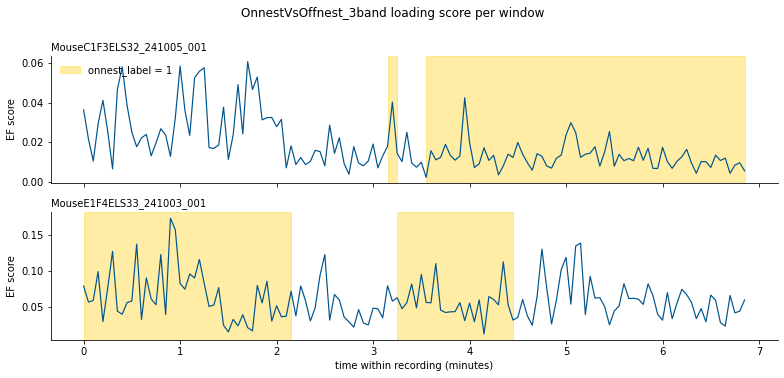

In [8]:
n = len(features)
fig, axes = plt.subplots(n, 1, figsize=(11, 2.6 * n), sharex=True, squeeze=False)

for ax, key in zip(axes[:, 0], sorted(features)):
    sub = per_window[per_window['recording'] == key]
    t = sub['t_start_s'].values / 60.0
    on = sub[LABEL_NAME].values == 1
    ax.plot(t, sub['score'].values, lw=1.2, color='#00558C')
    lo, hi = ax.get_ylim()
    ax.fill_between(t, lo, hi, where=on, step='mid',
                    color='#FFCD00', alpha=0.35, label=f'{LABEL_NAME} = 1')
    ax.set_ylim(lo, hi)
    ax.set_ylabel('EF score')
    ax.set_title(key, fontsize=10, loc='left')
    ax.spines[['top', 'right']].set_visible(False)
axes[0, 0].legend(loc='upper left', frameon=False)
axes[-1, 0].set_xlabel('time within recording (minutes)')
fig.suptitle(f'{EF_MODEL} loading score per window', y=1.0)
fig.tight_layout()

path = os.path.join(FIGURES_DIR, '01_scores_timeseries.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
print('saved ->', os.path.relpath(path, _repo))
plt.show()

saved -> examples/results/figures/02_auc_by_recording.png


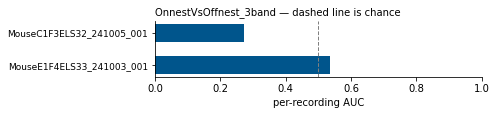

In [9]:
fig, ax = plt.subplots(figsize=(7, 0.7 + 0.5 * len(per_recording)))

y = np.arange(len(per_recording))
ax.barh(y, per_recording['auc'].values, color='#00558C', height=0.55)
ax.axvline(0.5, ls='--', lw=1, color='grey')
ax.set_yticks(y)
ax.set_yticklabels(per_recording['recording'].values, fontsize=9)
ax.set_xlabel('per-recording AUC')
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
ax.set_title(f'{EF_MODEL} — dashed line is chance', fontsize=10, loc='left')
fig.tight_layout()

path = os.path.join(FIGURES_DIR, '02_auc_by_recording.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
print('saved ->', os.path.relpath(path, _repo))
plt.show()

## 8. Which features drive the factor

dCSFA-NMF factorises each window as `x ≈ W.T @ s`, where `s` is the latent code
from the encoder and `W = model.get_W_nmf()` is the learned dictionary of shape
`(K, dim_in)`. Row `W[0, :]` is the spatial-spectral pattern of the supervised
factor: 36 channels (8 regions of power + 28 region pairs of coherence) × the
number of frequency bins.

**Scree plot** — sorts that row descending and draws each entry at its rank.
Triangles are power features, circles coherence; the dashed lines mark how many
entries cover 80 / 90 / 95 % of the factor's squared-L2 energy.

| Argument | Change it? | Meaning |
| --- | --- | --- |
| `W` | no | the NMF dictionary, `model.get_W_nmf()` |
| `k` | **yes** | which factor to inspect; `0` is the supervised one, `1..K-1` are unsupervised |
| `thresholds` | **yes** | cumulative-energy marks to draw |
| `n_power_rows` | no | how many of the 36 channels are power (8 regions), fixed by the feature layout |
| `ax` | **yes** | draw into an existing axis instead of a new figure |

**Dual-filter heatmap** — combines an absolute-strength filter (features inside
the top `abs_cum_ratio` of factor 0's cumulative squared-L2 contribution) with a
relative-uniqueness filter (factor 0 supplies at least `rel_val` of the
inter-factor sum). It picks the drawing style from the number of frequency
columns: bars for 3 guided bands, dots for 54 one-Hz bins. The Iowa-Gold border
marks features passing both filters.

| Argument | Change it? | Meaning |
| --- | --- | --- |
| `model` | **yes** | the loaded EF model |
| `train_dict` | **yes** | any feature dict from step 2 — only its `region` / `region_pair` / `freq_band` labels are used |
| `abs_cum_ratio` | **yes** | cumulative-energy cutoff for the absolute filter; higher keeps more features |
| `rel_val` | **yes** | minimum share of the inter-factor sum for the relative filter; higher is stricter |
| `verbose` | **yes** | print the intermediate tables |

The paper's figures use `abs_cum_ratio=0.7`, `rel_val=0.3`.

saved -> examples/results/figures/03_scree.png


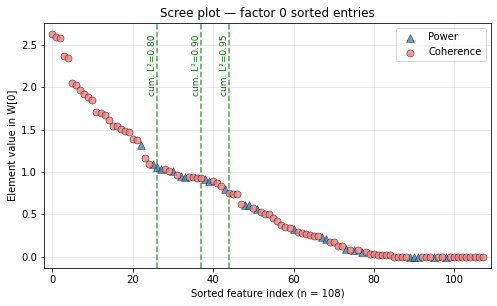

In [10]:
from electome.viz import plot_scree_W_nmf

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_scree_W_nmf(
    W            = model.get_W_nmf(),
    k            = 0,
    thresholds   = (0.8, 0.9, 0.95),
    n_power_rows = 8,
    ax           = ax,
)
path = os.path.join(FIGURES_DIR, '03_scree.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
print('saved ->', os.path.relpath(path, _repo))
plt.show()

absolute intensity range: 0 - 2.626039
relative uniqueness range: 0.0000 - 0.4132
features passing both filters: 8
saved -> examples/results/figures/04_features_3band.png


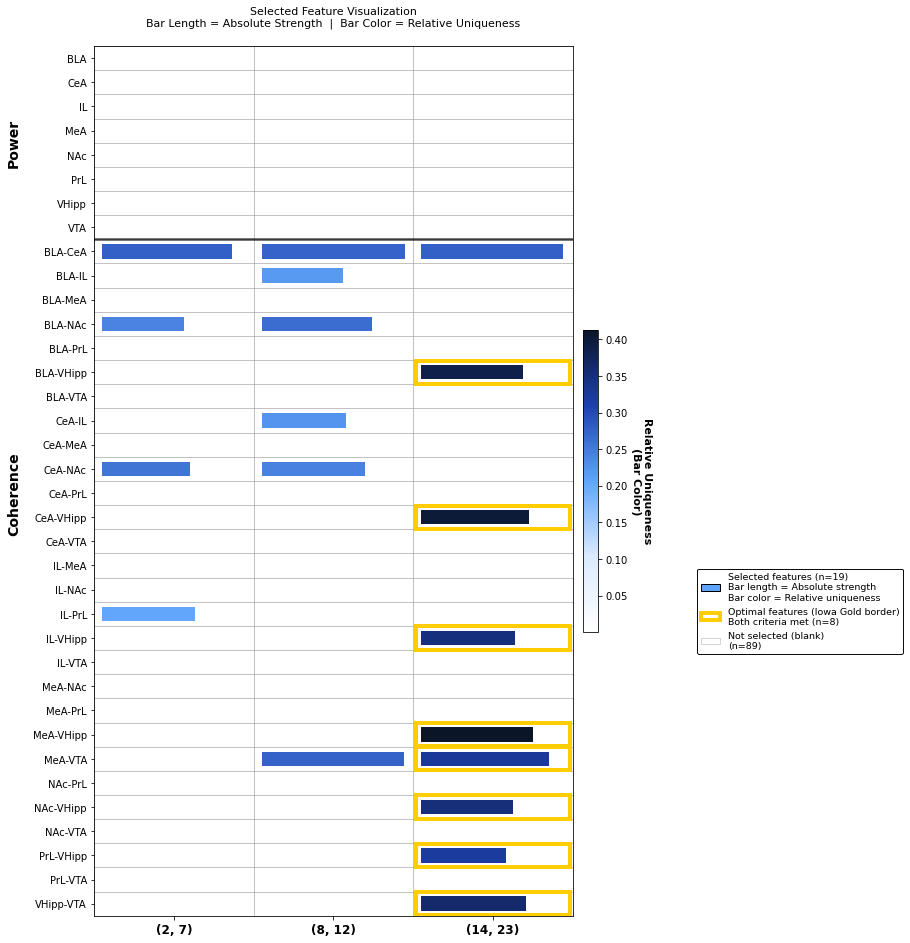

In [11]:
from electome.viz import plot_dual_filter

fig, abs_cut, rel_cut, both_cut, abs_full, rel_full = plot_dual_filter(
    model,
    features[sorted(features)[0]],
    abs_cum_ratio = 0.7,
    rel_val       = 0.3,
    verbose       = False,
)
path = os.path.join(FIGURES_DIR, '04_features_3band.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
print(f'features passing both filters: {int(both_cut.notna().sum().sum())}')
print('saved ->', os.path.relpath(path, _repo))
plt.show()

## 9. The same recordings at 1-Hz resolution

Only two settings change: `band='1Hz'` and a `_1Hz` model. The same three files
per recording are re-analysed at 54 one-Hz bins from 2 to 56 Hz, giving 1944
features instead of 108.

To make this your main analysis, set `BAND = '1Hz'` and
`EF_MODEL = 'OnnestVsOffnest_1Hz'` in section 2 and re-run from there — the cell
below just repeats the pipeline so both parameterisations appear in one pass.

In [12]:
BAND_1HZ  = '1Hz'
MODEL_1HZ = 'OnnestVsOffnest_1Hz'

features_1hz, skipped_1hz = batch_lfp_to_features(
    lfp_files        = LFP_DIR,
    chans_files      = CHANS_DIR,
    onnest_files     = BEHAVIOR_DIR,
    band             = BAND_1HZ,
    period           = PERIOD,
    fs               = FS,
    window_duration  = WINDOW_DURATION,
    label_name       = LABEL_NAME,
    output_dir       = FEATURES_DIR,
    strict           = False,
    verbose          = True,
    expected_regions = EXPECTED_REGIONS,
    recursive        = RECURSIVE,
)

model_1hz = load_ef_model(MODEL_1HZ)

_, per_recording_1hz, per_animal_1hz = score_recordings(
    model_1hz,
    features_1hz,
    label_name      = LABEL_NAME,
    window_duration = WINDOW_DURATION,
    model_name      = MODEL_1HZ,
    band            = BAND_1HZ,
    output_xlsx     = os.path.join(RESULTS_DIR, 'scores_1Hz.xlsx'),
)

print()
print(per_recording_1hz[['recording', 'band', 'model', 'n_windows',
                         'mean_score', 'auc']].to_string(index=False))
print(f'skipped: {skipped_1hz if skipped_1hz else "none"}')
print(f'written -> {os.path.relpath(os.path.join(RESULTS_DIR, "scores_1Hz.xlsx"), _repo)}')

  Inactive channels to remove: []
  OK   MouseC1F3ELS32_241005_001: X=(138, 1944), onnest_label=1 on 70/138
  Inactive channels to remove: []
  OK   MouseE1F4ELS33_241003_001: X=(138, 1944), onnest_label=1 on 69/138
2 recording(s) processed, 0 skipped.

                recording band               model  n_windows  mean_score    auc
MouseC1F3ELS32_241005_001  1Hz OnnestVsOffnest_1Hz        138      0.0380 0.2088
MouseE1F4ELS33_241003_001  1Hz OnnestVsOffnest_1Hz        138      0.0734 0.4596
skipped: none
written -> examples/results/scores_1Hz.xlsx


absolute intensity range: 0 - 2.532099
relative uniqueness range: 0.0000 - 0.3304
saved -> examples/results/figures/05_features_1Hz.png


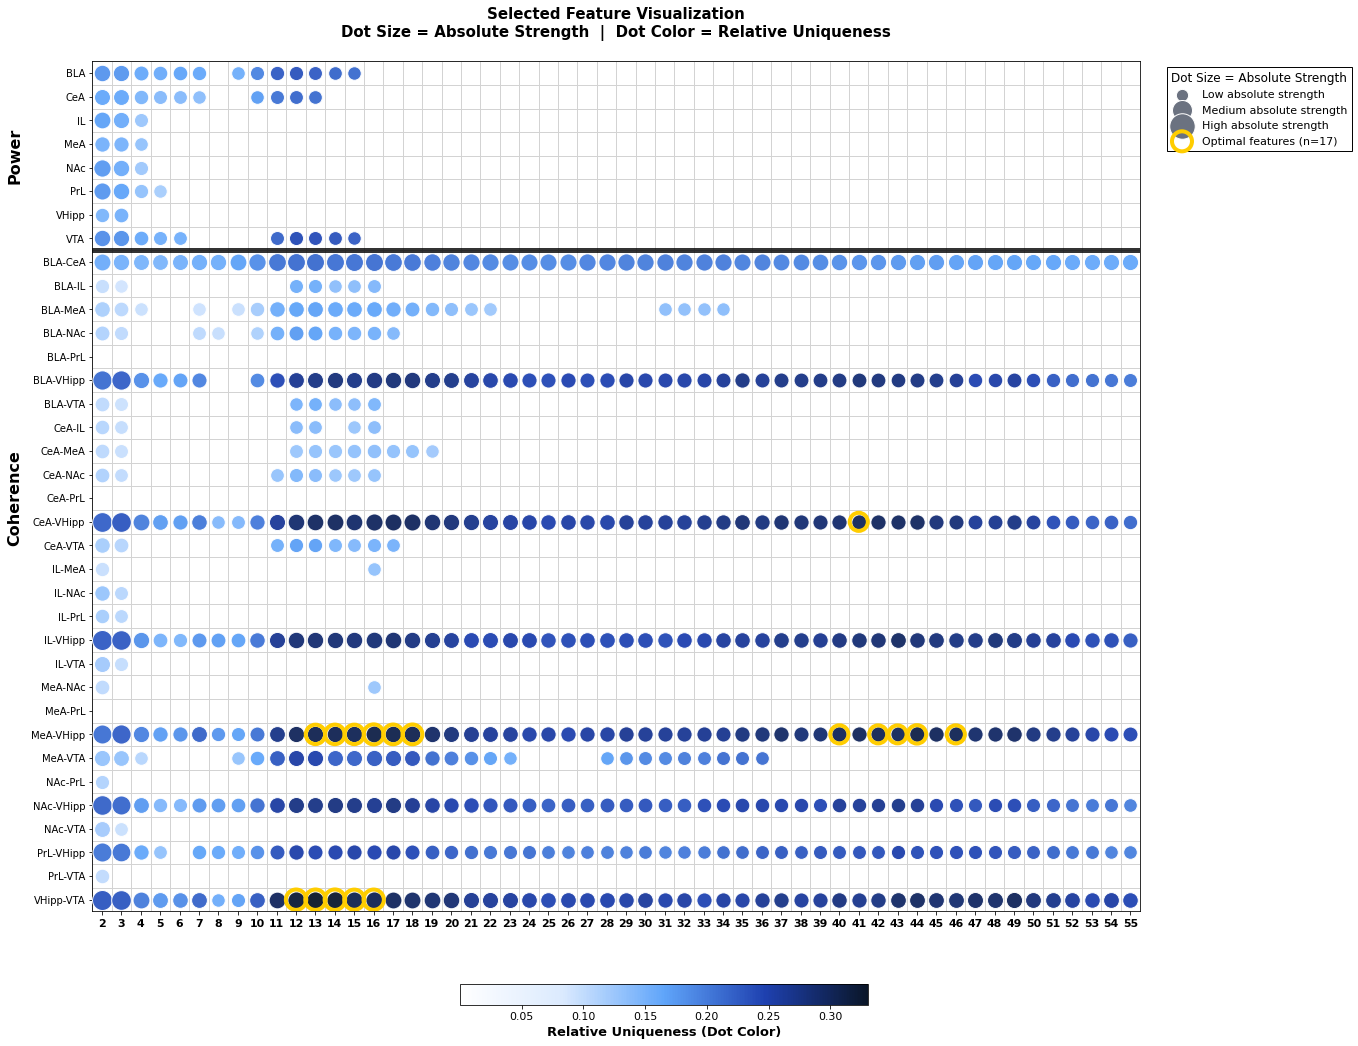

In [13]:
fig, *_ = plot_dual_filter(
    model_1hz,
    features_1hz[sorted(features_1hz)[0]],
    abs_cum_ratio = 0.7,
    rel_val       = 0.3,
    verbose       = False,
)
path = os.path.join(FIGURES_DIR, '05_features_1Hz.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
print('saved ->', os.path.relpath(path, _repo))
plt.show()

## 10. What was written — and what is inside it

Everything below is on disk now. `scores.xlsx` and the figures from this very
run are also committed to the repository, so you can look at them on GitHub
before running anything yourself.

The cell after the file list opens `scores.xlsx` back up and shows each sheet,
so you can see the column layout without Excel.

The feature pickles reload with `pickle.load(open(path, 'rb'))` and contain
exactly the dicts documented in section 4, so you can re-score them later
without re-running the LFP pipeline.

In [14]:
total = 0
for root, _dirs, files in os.walk(RESULTS_DIR):
    for fn in sorted(files):
        p = os.path.join(root, fn)
        mb = os.path.getsize(p) / 1e6
        total += mb
        print(f'  {mb:8.2f} MB  {os.path.relpath(p, RESULTS_DIR)}')
print(f'  {total:8.2f} MB  total in {os.path.relpath(RESULTS_DIR, _repo)}/')

      0.02 MB  scores.xlsx
      0.02 MB  scores_1Hz.xlsx
      4.31 MB  features/MouseC1F3ELS32_241005_001_1Hz.pkl
      0.25 MB  features/MouseC1F3ELS32_241005_001_3band.pkl
      4.31 MB  features/MouseE1F4ELS33_241003_001_1Hz.pkl
      0.25 MB  features/MouseE1F4ELS33_241003_001_3band.pkl
      0.16 MB  figures/01_scores_timeseries.png
      0.02 MB  figures/02_auc_by_recording.png
      0.07 MB  figures/03_scree.png
      0.14 MB  figures/04_features_3band.png
      0.63 MB  figures/05_features_1Hz.png
     10.16 MB  total in examples/results/


In [15]:
# What scores.xlsx actually contains, read back from the file on disk.
for sheet in ('per_window', 'per_recording', 'per_animal'):
    df = pd.read_excel(SCORES_XLSX, sheet_name=sheet)
    print(f'=== sheet "{sheet}" — {len(df)} rows x {len(df.columns)} columns ===')
    print(df.head(3).to_string(index=False))
    if len(df) > 3:
        print(f'   ... {len(df) - 3} more rows')
    print()

=== sheet "per_window" — 276 rows x 8 columns ===
                recording       mouse_id period  window  t_start_s  t_end_s  score  onnest_label
MouseC1F3ELS32_241005_001 MouseC1F3ELS32     P8       0          0        3 0.0362             0
MouseC1F3ELS32_241005_001 MouseC1F3ELS32     P8       1          3        6 0.0216             0
MouseC1F3ELS32_241005_001 MouseC1F3ELS32     P8       2          6        9 0.0104             0
   ... 273 more rows

=== sheet "per_recording" — 2 rows x 10 columns ===
                recording       mouse_id period  band                 model  n_windows  n_onnest_label_1  n_onnest_label_0  mean_score    auc
MouseC1F3ELS32_241005_001 MouseC1F3ELS32     P8 3band OnnestVsOffnest_3band        138                70                68      0.0186 0.2721
MouseE1F4ELS33_241003_001 MouseE1F4ELS33     P8 3band OnnestVsOffnest_3band        138                69                69      0.0599 0.5356

=== sheet "per_animal" — 2 rows x 7 columns ===
      mouse_i

## 11. Running this on your own recordings

**Step by step:**

1. **Sort your files into three folders** — all `_LFP.mat` in one, all
   `_CHANS.mat` in one, all scoring sheets in one. Groups and days mixed
   together; no per-animal sub-folders (section 1).
2. **Edit section 2 only.** Set `LFP_DIR`, `CHANS_DIR`, `BEHAVIOR_DIR` to your
   three folders, and `FS` to your sampling rate. Set `BEHAVIOR_DIR = None` if
   you have no scoring.
3. **Pick the model.** `EF_MODEL` and the matching `BAND` from the table in
   section 5; set `LABEL_NAME` to the behaviour you scored.
4. **If any animal has more than one recording**, set `MOUSE_ID` (section 4) —
   otherwise each session is counted as a separate animal.
5. **Run the notebook top to bottom** (`Run` → `Run All Cells`, or
   `jupyter nbconvert --to notebook --execute examples/tutorial.ipynb --output
   tutorial_run.ipynb` from a terminal).
6. **Check two things before trusting anything**: `problems` printed in
   section 3, and `skipped` printed in section 4. Both empty means every
   recording was found and processed.
7. **Collect your results** from `RESULTS_DIR`:
   `scores.xlsx` (the numbers), `features/*.pkl` (re-usable features),
   `figures/*.png` (the plots).

**Where do experimental groups come in?** Nowhere in this notebook — it scores
recordings, it does not compare conditions. Add your grouping afterwards, in
`scores.xlsx`: the `mouse_id` and `recording` columns identify each row, so a
lookup column mapping animal → group is all you need. Comparing groups on
`mean_score` is the one thing to avoid; see "How to read these numbers" in
section 6.

**Questions you may have next:**

| Question | Answer |
| --- | --- |
| I recorded **more than these 8 regions** | Set `CHANACTIVE = 0` for the extra sites in your `_CHANS.mat`. They are dropped before the region check, and the recording then goes through normally (verified). Leaving them active fails with "unrecognised: …". |
| I recorded **fewer than 8** | These models cannot be used. All 108 (or 1944) feature columns are defined over the 8 regions and their 28 pairs; there is no reduced version. |
| Do I need to **filter or detrend** first? | No. Feed the raw traces. Welch detrends each segment, and the band integration ignores everything outside 2–56 Hz. |
| Can I run this **as a script** instead of a notebook? | Yes — the four calls in sections 3, 4, 5 and 6 are the whole pipeline; the README has them as a 20-line snippet. |
| Can I **re-score saved features** without redoing the LFP step? | Yes. `pickle.load(open('results/features/<key>_3band.pkl','rb'))` gives back the same dict; pass a `{key: dict}` mapping to `score_recordings`. |
| My recording is **hours long** | Fine — 2 h 21 min takes well under a minute per band. Budget ~7× the `.mat` file size in RAM; measured numbers just below. |

### What it costs on real recordings

Measured on one full-length recording of this dataset (2 h 21 min, 32 channels
at 1000 Hz, a 427 MB `.mat`) on a laptop CPU:

| Band | Windows | Time | Peak RAM |
| --- | --- | --- | --- |
| `3band` | 2821 | 16 s | 3.0 GB |
| `1Hz` | 2821 | 20 s | 3.0 GB |

Both timings include reading the `.mat` and averaging the sites (9 s of the
total, shared between the two) but not writing the pickle.

Almost all of the memory is the raw traces: the `.mat` is read whole, so budget
roughly 7× the file size. Recordings are processed one at a time, so a batch of
twenty costs twenty times the *time* but not twenty times the memory. If you are
short on RAM, run the batch in chunks rather than all at once.

### If your scoring is not already in seconds

`START` / `STOP` must be seconds from the start of that recording. Two common
conversions, done in the spreadsheet or in pandas before saving:

* **frame numbers** — divide by the video frame rate;
* **video clock offset from the recording start** — subtract the offset, so
  that 0 is the first LFP sample. Getting this wrong shifts every label and
  quietly lowers the AUC, and nothing can detect it for you.

Bouts may be in any order and may be a single row; the tutorial's two example
recordings have 2 bouts each.

### Requirements, restated

| What | Requirement |
| --- | --- |
| Regions | `BLA, CeA, IL, MeA, NAc, PrL, VHipp, VTA`. Variants (`Nac`, `NAcc`, `vHipp`, `VHPC`, `ACB`, `PL`, and the `BLS` typo) are recognised; anything else is named in the error. Add yours to `electome.lfp_features.REGION_ALIASES`. |
| Sampling rate | A whole multiple of 100 Hz (`3band`) or 200 Hz (`1Hz`). Resample first if not. |
| Recording length | At least one window; more is much better, since the AUC is computed across windows. |
| Scoring times | `START` / `STOP` in seconds from the start of *that* recording — not wall-clock, not video time. |
| File format | MATLAB v6, v7 and v7.3 (HDF5) all read. The `lpne` package is not required. |
| Units | Irrelevant to the *score* — power is log-transformed and min-max normalised per recording. They do decide whether a recording is accepted at all; see the log10 note at the end of this section. |

### If something goes wrong

| Message | What it means |
| --- | --- |
| `no matching '_chans.mat' file` | That recording has no CHANS file under any of the four matching passes — check the spelling, or set `chans_suffix` |
| `N CHANS files share the same normalised name` | Two candidates are indistinguishable once case and `_`/`-` are folded; rename one |
| `recording regions do not match the model's` | Lists exactly which regions are missing or unrecognised |
| `both canonicalise to 'NAc'` | Two channel prefixes in one recording map to the same region |
| `fs=... cannot be decimated to new_fs=... by an integer factor` | Your sampling rate is not a whole multiple of 100 / 200 Hz |
| `recording is ... s ..., shorter than one 3.0 s window` | Too short to produce a single feature window |
| `no 'CHANACTIVE' variable` | The CHANS file lacks one of the two variables the pipeline reads |
| `Cannot find START or STOP column` | The scoring sheet has no such columns (checked case-insensitively) |
| `is a MATLAB v7.3 (HDF5) file; reading it needs h5py` | `pip install h5py` (it is a declared dependency, so this only appears in a partial install) |
| `mat1 and mat2 shapes cannot be multiplied` | A `3band` feature matrix was fed to a `_1Hz` model or vice versa |
| `Found N negative values after log10; file will not be saved` | The recording is **rejected**, and `skipped` will name it. See the note below — this is the one you are most likely to hit. |

**About that last one.** `normalize_features_per_file` requires *every* band
power in the file to be ≥ 1 before taking `log10`, and rejects the whole
recording if a single value is not. This is a check in the released code, and
it is stricter than what produced this paper's own training features — those
contain values it would reject. Two consequences worth knowing before you run
a batch:

* It depends on your **amplitude scale**, which is otherwise irrelevant to the
  result. Traces on a smaller numeric scale than this lab's will be rejected
  wholesale. Multiplying every channel by a constant fixes it and changes
  nothing else — scores are invariant to that constant (measured above).
* Because the test is over all windows at once, **longer recordings are more
  likely to trip it**. At `band='1Hz'` each band is only 1 Hz wide, so the
  integrated power is ~54× smaller than a guided band and sits close to the
  threshold. On this dataset, a 7-minute excerpt passes while the full 2 h 21 min
  recording it came from is rejected at 1 Hz — on 20 values out of 5.5 million.

If a recording you care about is rejected, the practical options are to rescale
the traces by a constant, or to process it in segments and concatenate the
resulting scores. Note that segmenting changes the normalisation, so keep the
segments the same length across recordings you intend to compare.